<a href="https://colab.research.google.com/github/imnaveenks/Australian-Energy-Market-Analysis/blob/main/Energy_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving PRICE_AND_DEMAND_202501_VIC1.csv to PRICE_AND_DEMAND_202501_VIC1.csv
Saving PRICE_AND_DEMAND_202502_VIC1.csv to PRICE_AND_DEMAND_202502_VIC1.csv
Saving PRICE_AND_DEMAND_202503_VIC1.csv to PRICE_AND_DEMAND_202503_VIC1.csv
Saving PRICE_AND_DEMAND_202504_VIC1.csv to PRICE_AND_DEMAND_202504_VIC1.csv
Saving PRICE_AND_DEMAND_202505_VIC1.csv to PRICE_AND_DEMAND_202505_VIC1.csv
Saving PRICE_AND_DEMAND_202506_VIC1.csv to PRICE_AND_DEMAND_202506_VIC1.csv
Saving PRICE_AND_DEMAND_202507_VIC1.csv to PRICE_AND_DEMAND_202507_VIC1.csv
Saving PRICE_AND_DEMAND_202508_VIC1.csv to PRICE_AND_DEMAND_202508_VIC1.csv
Saving PRICE_AND_DEMAND_202509_VIC1.csv to PRICE_AND_DEMAND_202509_VIC1.csv
Saving PRICE_AND_DEMAND_202510_VIC1.csv to PRICE_AND_DEMAND_202510_VIC1.csv
Saving PRICE_AND_DEMAND_202511_VIC1.csv to PRICE_AND_DEMAND_202511_VIC1.csv
Saving PRICE_AND_DEMAND_202512_VIC1.csv to PRICE_AND_DEMAND_202512_VIC1.csv


In [2]:
import pandas as pd
import glob

files = glob.glob('PRICE_AND_DEMAND_*.csv')
df = pd.concat([pd.read_csv(f) for f in files])

print(df.shape)
print(df.head())


(105120, 5)
  REGION       SETTLEMENTDATE  TOTALDEMAND     RRP PERIODTYPE
0   VIC1  2025/03/01 00:05:00      4558.66  144.97      TRADE
1   VIC1  2025/03/01 00:10:00      4492.06  122.49      TRADE
2   VIC1  2025/03/01 00:15:00      4456.54  120.00      TRADE
3   VIC1  2025/03/01 00:20:00      4400.88  119.81      TRADE
4   VIC1  2025/03/01 00:25:00      4403.96  120.56      TRADE


In [3]:
import sqlite3

conn = sqlite3.connect('energy.db')
df.to_sql('energy', conn, if_exists='replace', index=False)

print("Database created!")


Database created!


In [4]:
query = """
SELECT *
FROM energy
LIMIT 5
"""

result = pd.read_sql(query, conn)
print(result)


  REGION       SETTLEMENTDATE  TOTALDEMAND     RRP PERIODTYPE
0   VIC1  2025/03/01 00:05:00      4558.66  144.97      TRADE
1   VIC1  2025/03/01 00:10:00      4492.06  122.49      TRADE
2   VIC1  2025/03/01 00:15:00      4456.54  120.00      TRADE
3   VIC1  2025/03/01 00:20:00      4400.88  119.81      TRADE
4   VIC1  2025/03/01 00:25:00      4403.96  120.56      TRADE


In [6]:
query = """
SELECT
    substr(SETTLEMENTDATE, 6, 2) AS Month,
    ROUND(AVG(TOTALDEMAND), 2) AS Avg_Demand,
    ROUND(AVG(RRP), 2) AS Avg_Price
FROM energy
GROUP BY Month
ORDER BY Month
"""

result = pd.read_sql(query, conn)
print(result)



   Month  Avg_Demand  Avg_Price
0     01     4408.21      48.35
1     02     4829.72      68.54
2     03     4683.50      61.76
3     04     4456.75      74.75
4     05     5035.46      78.04
5     06     5869.27     264.60
6     07     5941.97      82.13
7     08     5550.81      93.19
8     09     4821.90      55.28
9     10     4444.89      51.36
10    11     4335.11      31.93
11    12     4190.09      27.50


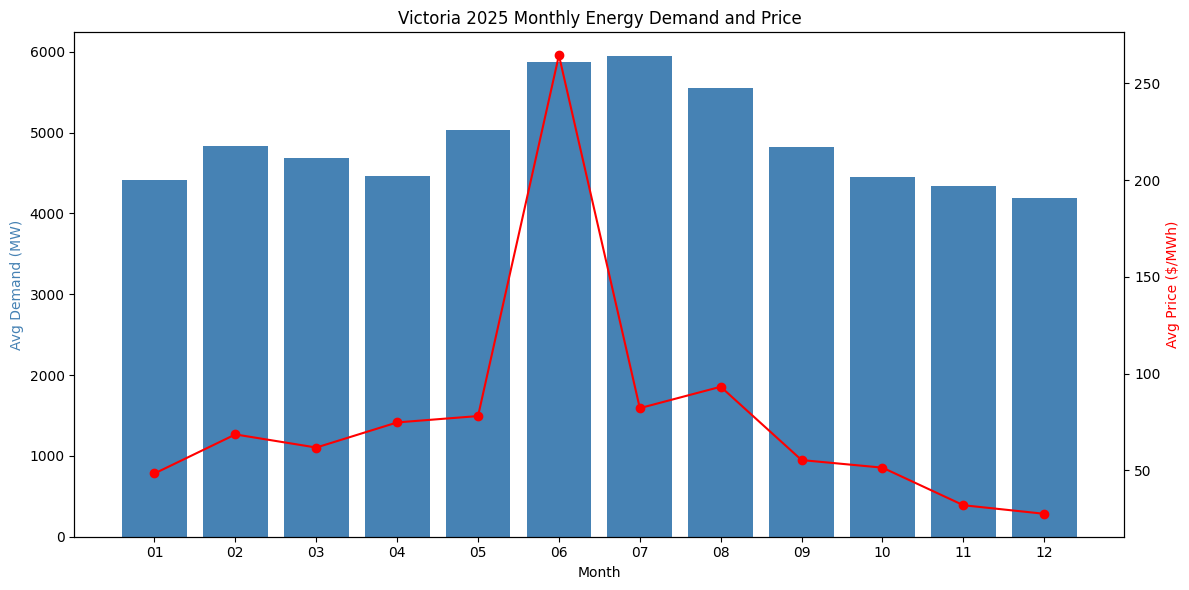

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(result['Month'], result['Avg_Demand'], color='steelblue', label='Avg Demand')
ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Demand (MW)', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(result['Month'], result['Avg_Price'], color='red', marker='o', label='Avg Price')
ax2.set_ylabel('Avg Price ($/MWh)', color='red')

plt.title('Victoria 2025 Monthly Energy Demand and Price')
plt.tight_layout()
plt.show()


In [8]:
query = """
SELECT
    substr(SETTLEMENTDATE, 12, 2) AS Hour,
    ROUND(AVG(TOTALDEMAND), 2) AS Avg_Demand
FROM energy
GROUP BY Hour
ORDER BY Avg_Demand DESC
"""

result_hour = pd.read_sql(query, conn)
print(result_hour)


   Hour  Avg_Demand
0    18     6289.40
1    19     6205.92
2    17     5960.61
3    20     5935.07
4    21     5550.59
5    07     5312.62
6    16     5287.91
7    22     5146.60
8    08     5122.36
9    06     5106.15
10   23     5045.01
11   00     4756.14
12   09     4681.25
13   05     4633.63
14   15     4604.52
15   01     4486.90
16   04     4308.99
17   02     4280.68
18   10     4256.51
19   03     4214.51
20   14     4156.16
21   11     3988.92
22   13     3932.41
23   12     3885.13


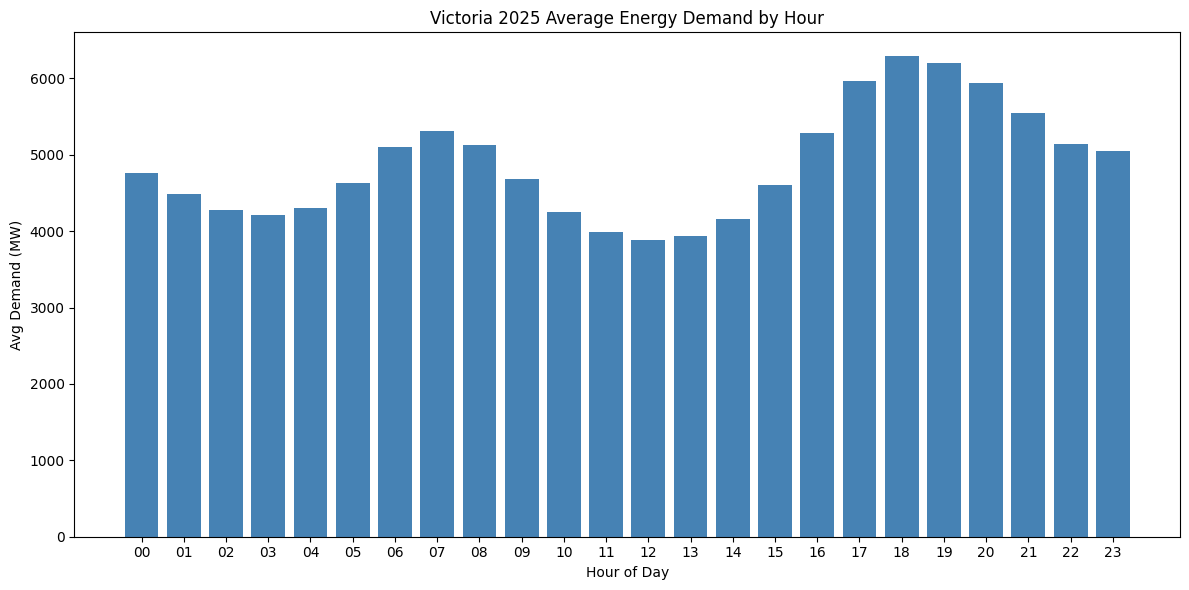

In [10]:
import matplotlib.pyplot as plt

result_hour_sorted = result_hour.sort_values('Hour')

plt.figure(figsize=(12, 6))
plt.bar(result_hour_sorted['Hour'], result_hour_sorted['Avg_Demand'], color='steelblue')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Demand (MW)')
plt.title('Victoria 2025 Average Energy Demand by Hour')
plt.tight_layout()
plt.show()


In [11]:
query = """
SELECT
    substr(SETTLEMENTDATE, 1, 10) AS Date,
    ROUND(AVG(RRP), 2) AS Avg_Price,
    ROUND(MAX(RRP), 2) AS Max_Price
FROM energy
GROUP BY Date
ORDER BY Avg_Price DESC
LIMIT 10
"""

result_days = pd.read_sql(query, conn)
print(result_days)


         Date  Avg_Price  Max_Price
0  2025/06/26    2048.73   15974.34
1  2025/06/12    1786.18   17500.00
2  2025/06/11     603.84   10486.13
3  2025/06/18     316.73    3758.92
4  2025/06/27     315.50    3709.12
5  2025/02/03     277.02   11346.81
6  2025/06/13     254.09    1005.58
7  2025/08/18     233.86     979.87
8  2025/06/30     210.24     388.72
9  2025/08/19     207.93     869.38


In [12]:
query = """
SELECT
    ROUND(TOTALDEMAND, -2) AS Demand_Bucket,
    ROUND(AVG(RRP), 2) AS Avg_Price,
    COUNT(*) AS Count
FROM energy
GROUP BY Demand_Bucket
ORDER BY Demand_Bucket
"""

result_corr = pd.read_sql(query, conn)
print(result_corr)


      Demand_Bucket  Avg_Price  Count
0            1225.0    -105.45      1
1            1230.0    -199.97      1
2            1239.0    -133.79      1
3            1242.0    -165.65      1
4            1246.0    -170.72      1
...             ...        ...    ...
6690         9405.0     311.38      1
6691         9433.0     365.41      1
6692         9446.0     896.95      1
6693         9457.0     500.08      1
6694         9491.0     361.61      1

[6695 rows x 3 columns]


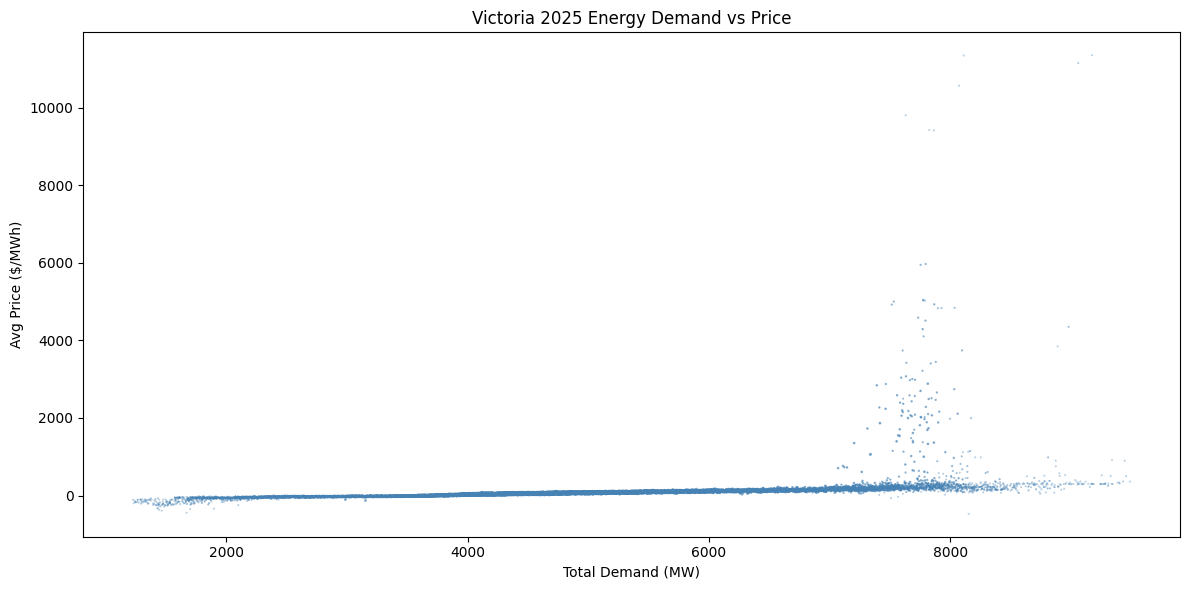

In [13]:
plt.figure(figsize=(12, 6))
plt.scatter(result_corr['Demand_Bucket'], result_corr['Avg_Price'],
            s=result_corr['Count']/10, alpha=0.6, color='steelblue')
plt.xlabel('Total Demand (MW)')
plt.ylabel('Avg Price ($/MWh)')
plt.title('Victoria 2025 Energy Demand vs Price')
plt.tight_layout()
plt.show()
